In [16]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

In [17]:
config_str = "config1"
map_path = "../maps/map1.json"
triangles_path = "../results/" + config_str +"/triangles.json"
convex_regions_path = "../results/" + config_str +"/convex_regions.json"
traj_path = "../results/" + config_str +"/trajectory.csv"

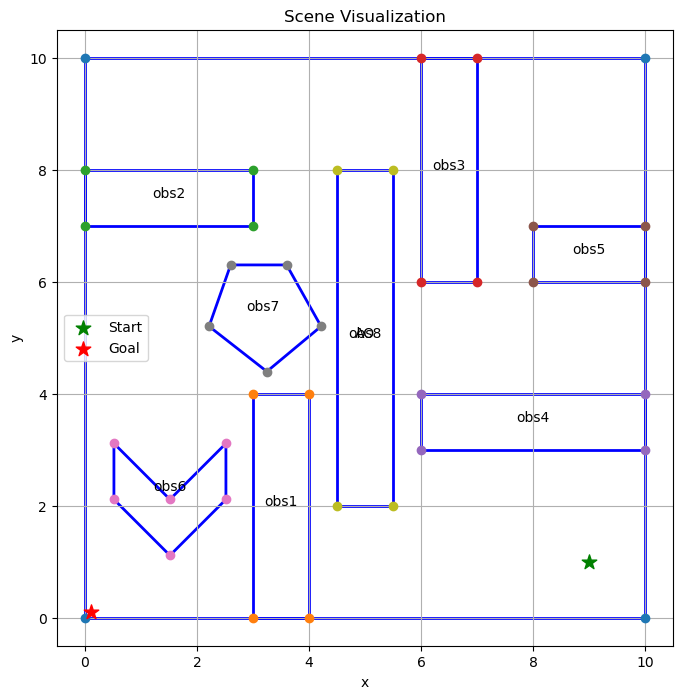

In [18]:


# Load JSON from file
with open(map_path, "r") as f:
    scene = json.load(f)

fig, ax = plt.subplots(figsize=(8, 8))

for shape in scene["shapes"]:
    pts = shape["points"]

    # Draw polygon
    poly = Polygon(
        pts,
        closed=True,
        fill=False,
        edgecolor="blue",
        linewidth=2
    )
    ax.add_patch(poly)

    # Plot vertices
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.plot(xs, ys, "o", )

    # Label shape at centroid
    cx = sum(xs) / len(xs)
    cy = sum(ys) / len(ys)
    ax.text(cx, cy, shape["name"], fontsize=10, ha="center")

# Formatting
sx, sy = 9.0, 1.0
gx, gy = 0.1, 0.1
ax.scatter(sx, sy, s=120, c="green", marker="*", zorder=5, label="Start")
ax.scatter(gx, gy, s=120, c="red", marker="*", zorder=5, label="Goal")
ax.set_aspect("equal")
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scene Visualization")
ax.legend()

plt.show()

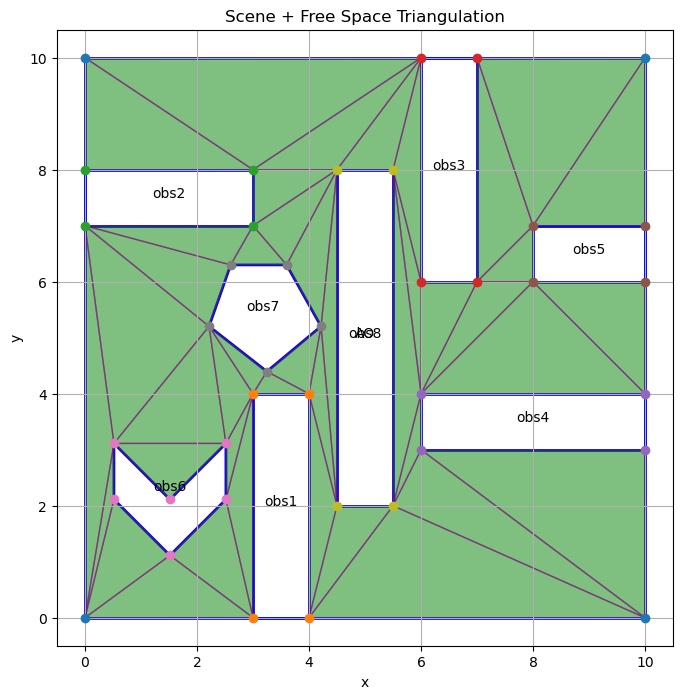

In [19]:
# Load original map
with open(map_path, "r") as f:
    scene = json.load(f)

# Load triangles
with open(triangles_path, "r") as f:
    tri_data = json.load(f)

fig, ax = plt.subplots(figsize=(8, 8))

# --- Plot original shapes (blue) ---
for shape in scene["shapes"]:
    pts = shape["points"]

    poly = Polygon(
        pts,
        closed=True,
        fill=False,
        edgecolor="blue",
        linewidth=2
    )
    ax.add_patch(poly)

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.plot(xs, ys, "o")

    cx = sum(xs) / len(xs)
    cy = sum(ys) / len(ys)
    ax.text(cx, cy, shape["name"], fontsize=10, ha="center")


# --- Plot triangles (green) ---
for tri in tri_data["convex_regions"]:
    pts = tri["points"]

    poly = Polygon(
        pts,
        closed=True,
        fill=True,              # fill them so you can see regions
        edgecolor="purple",
        facecolor="green",
        alpha=0.5,              # transparency so obstacles still visible
        linewidth=1
    )
    ax.add_patch(poly)


# Formatting
ax.set_aspect("equal")
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scene + Free Space Triangulation")

plt.show()

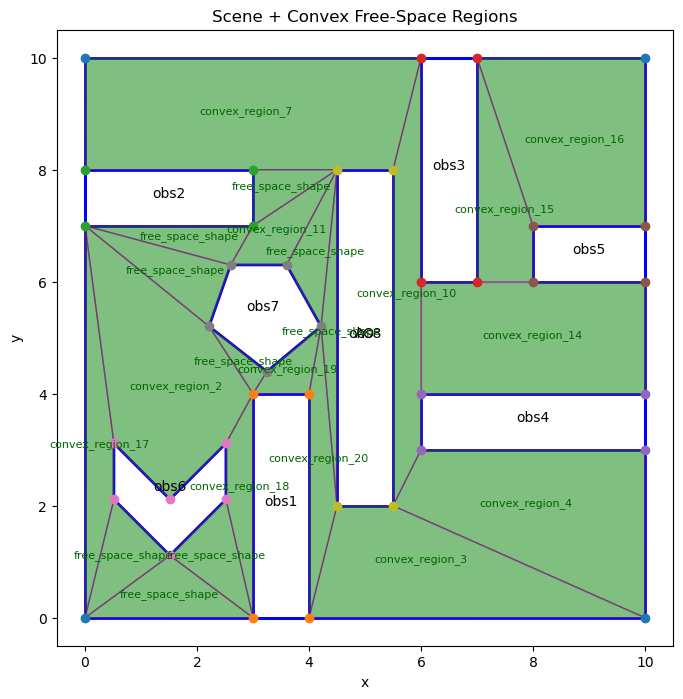

In [20]:

# Load original map
with open(map_path, "r") as f:
    scene = json.load(f)

# Load convex regions
with open(convex_regions_path, "r") as f:
    region_data = json.load(f)

fig, ax = plt.subplots(figsize=(8, 8))

# --- Plot original shapes (blue) ---
for shape in scene["shapes"]:
    pts = shape["points"]

    poly = Polygon(
        pts,
        closed=True,
        fill=False,
        edgecolor="blue",
        linewidth=2
    )
    ax.add_patch(poly)

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.plot(xs, ys, "o")

    cx = sum(xs) / len(xs)
    cy = sum(ys) / len(ys)
    ax.text(cx, cy, shape["name"], fontsize=10, ha="center")

# --- Plot convex regions (green) ---
for region in region_data["convex_regions"]:
    pts = region["points"]
    # ax.grid(True)

    poly = Polygon(
        pts,
        closed=True,
        fill=True,
        edgecolor="purple",
        facecolor="green",
        alpha=0.5,
        linewidth=1.0
    )
    ax.add_patch(poly)

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    cx = sum(xs) / len(xs)
    cy = sum(ys) / len(ys)
    ax.text(cx, cy, region["name"], fontsize=8, ha="center", color="darkgreen")

# Formatting
ax.set_aspect("equal")
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scene + Convex Free-Space Regions")

plt.show()

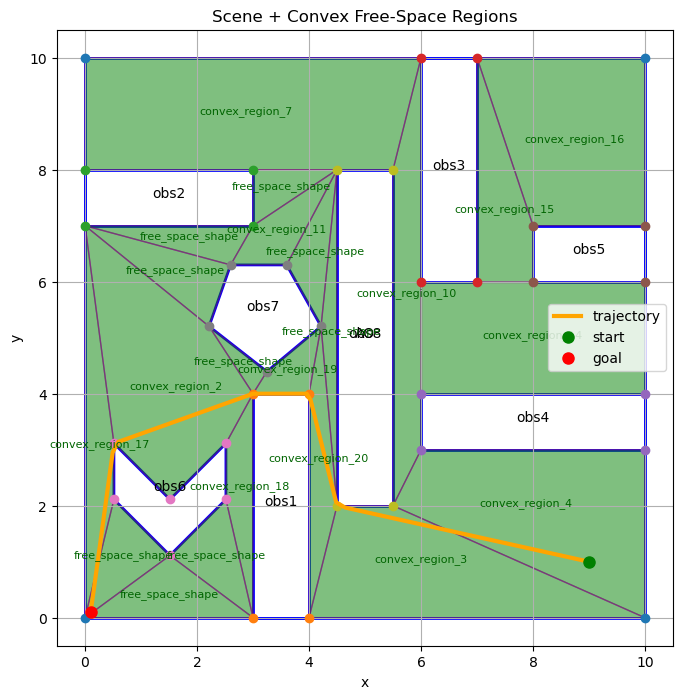

In [21]:
import csv

# Load trajectory
traj_x = []
traj_y = []

with open(traj_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        traj_x.append(float(row["x"]))
        traj_y.append(float(row["y"]))
# Load original map
with open(map_path, "r") as f:
    scene = json.load(f)

# Load convex regions
with open(convex_regions_path, "r") as f:
    region_data = json.load(f)

fig, ax = plt.subplots(figsize=(8, 8))

# --- Plot original shapes (blue) ---
for shape in scene["shapes"]:
    pts = shape["points"]

    poly = Polygon(
        pts,
        closed=True,
        fill=False,
        edgecolor="blue",
        linewidth=2
    )
    ax.add_patch(poly)

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.plot(xs, ys, "o")

    cx = sum(xs) / len(xs)
    cy = sum(ys) / len(ys)
    ax.text(cx, cy, shape["name"], fontsize=10, ha="center")

# --- Plot convex regions (green) ---
for region in region_data["convex_regions"]:
    pts = region["points"]

    poly = Polygon(
        pts,
        closed=True,
        fill=True,
        edgecolor="purple",
        facecolor="green",
        alpha=0.5,
        linewidth=1
    )
    ax.add_patch(poly)

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    cx = sum(xs) / len(xs)
    cy = sum(ys) / len(ys)
    ax.text(cx, cy, region["name"], fontsize=8, ha="center", color="darkgreen")

# Formatting
ax.set_aspect("equal")
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scene + Convex Free-Space Regions")

ax.plot(traj_x, traj_y, "-", linewidth=3, label="trajectory", color = "orange")

# Mark start and goal
ax.plot(traj_x[0], traj_y[0], "go", markersize=8, label="start")
ax.plot(traj_x[-1], traj_y[-1], "ro", markersize=8, label="goal")

ax.legend()

plt.show()

In [22]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.animation import FuncAnimation


# =========================
# User settings
# =========================
config_str = "config2"
CSV_PATH = "../results/" + config_str +"/trajectory.csv"
MAP_PATH = "../maps/map2.json"

# Robot parameters
LINK_LENGTHS = [1.5, 1.5, 1.5]   # lengths of the 3 links
BASE = np.array([5.0, 0.0])      # base position of the arm in workspace

# Animation settings
INTERVAL_MS = 100                # delay between frames in milliseconds
SHOW_TRACE = True               # set True to show end-effector trace
SAVE_MP4 = True               # set True if you want to save animation
OUTPUT_MP4 = f"robot_animation_{config_str}.mp4"


# =========================
# Helpers
# =========================
def load_map(map_path):
    with open(map_path, "r") as f:
        data = json.load(f)
    return data


def get_workspace_bounds(map_data):
    ao_shape = None
    for shape in map_data["shapes"]:
        if shape["type"].lower() == "ao":
            ao_shape = np.array(shape["points"], dtype=float)
            break

    if ao_shape is None:
        raise ValueError("No AO shape found in map JSON.")

    xmin = np.min(ao_shape[:, 0])
    xmax = np.max(ao_shape[:, 0])
    ymin = np.min(ao_shape[:, 1])
    ymax = np.max(ao_shape[:, 1])
    return xmin, xmax, ymin, ymax


def forward_kinematics(q, link_lengths, base):
    """
    q: [q1, q2, q3] joint angles in radians
    Returns:
        xs, ys for base, joint1, joint2, end-effector
    """
    q1, q2, q3 = q
    l1, l2, l3 = link_lengths

    p0 = np.array(base)

    theta1 = q1
    p1 = p0 + np.array([l1 * np.cos(theta1), l1 * np.sin(theta1)])

    theta2 = q1 + q2
    p2 = p1 + np.array([l2 * np.cos(theta2), l2 * np.sin(theta2)])

    theta3 = q1 + q2 + q3
    p3 = p2 + np.array([l3 * np.cos(theta3), l3 * np.sin(theta3)])

    xs = [p0[0], p1[0], p2[0], p3[0]]
    ys = [p0[1], p1[1], p2[1], p3[1]]
    return xs, ys


def draw_map(ax, map_data):
    for shape in map_data["shapes"]:
        pts = np.array(shape["points"], dtype=float)
        shape_type = shape["type"].lower()

        if shape_type == "ao":
            patch = Polygon(
                pts, closed=True, fill=False, edgecolor="black", linewidth=2
            )
            ax.add_patch(patch)

        elif shape_type == "obstacle":
            patch = Polygon(
                pts, closed=True, facecolor="gray", edgecolor="black", alpha=0.7
            )
            ax.add_patch(patch)



    

In [23]:
# Load files
traj = pd.read_csv(CSV_PATH)
map_data = load_map(MAP_PATH)

required_cols = {"t", "q1", "q2", "q3"}
if not required_cols.issubset(traj.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

times = traj["t"].to_numpy()
q_traj = traj[["q1", "q2", "q3"]].to_numpy()

# Plot setup
xmin, xmax, ymin, ymax = get_workspace_bounds(map_data)

fig, ax = plt.subplots(figsize=(8, 8))
draw_map(ax, map_data)

ax.set_xlim(xmin - 1, xmax + 1)
ax.set_ylim(ymin - 1, ymax + 1)
ax.set_aspect("equal")
ax.set_title("3-Joint Robot Arm Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

# Initial robot drawing
xs, ys = forward_kinematics(q_traj[0], LINK_LENGTHS, BASE)
arm_line, = ax.plot(xs, ys, "-o", linewidth=3, markersize=6, label="robot arm")
time_text = ax.text(
    0.02, 0.95, f"t = {times[0]:.2f}",
    transform=ax.transAxes, fontsize=12, verticalalignment="top"
)

ee_trace_x = []
ee_trace_y = []
trace_line = None
if SHOW_TRACE:
    trace_line, = ax.plot([], [], "--", linewidth=1.5, label="end-effector trace")

ax.legend()

def update(frame_idx):
    q = q_traj[frame_idx]
    xs, ys = forward_kinematics(q, LINK_LENGTHS, BASE)

    arm_line.set_data(xs, ys)
    time_text.set_text(f"t = {times[frame_idx]:.2f}")

    if SHOW_TRACE:
        ee_trace_x.append(xs[-1])
        ee_trace_y.append(ys[-1])
        trace_line.set_data(ee_trace_x, ee_trace_y)
        return arm_line, trace_line, time_text

    return arm_line, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(q_traj),
    interval=INTERVAL_MS,
    blit=False,
    repeat=False
)

if SAVE_MP4:
    anim.save(OUTPUT_MP4, writer="ffmpeg", fps=max(1, 1000 // INTERVAL_MS))
    print(f"Saved animation to {OUTPUT_MP4}")

plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '../results/config2/trajectory.csv'

In [24]:
config_str = "config7"
CSV_PATH = "../results/" + config_str +"/trajectory.csv"
MAP_PATH = "../maps/map2.json"

# Robot parameters
LINK_LENGTHS = [2.0, 2.0, 2.0]   # lengths of the 3 links
BASE = np.array([5.0, 0.0])      # base position of the arm in workspace

# Animation settings
INTERVAL_MS = 100                # delay between frames in milliseconds
SHOW_TRACE = True              # set True to show end-effector trace
SAVE_MP4 = True                 # set True if you want to save animation
OUTPUT_MP4 = f"robot_animation_{config_str}.mp4"

traj = pd.read_csv(CSV_PATH)
map_data = load_map(MAP_PATH)

required_cols = {"t", "q1", "q2", "q3"}
if not required_cols.issubset(traj.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

times = traj["t"].to_numpy()
q_traj = traj[["q1", "q2", "q3"]].to_numpy()

# Plot setup
xmin, xmax, ymin, ymax = get_workspace_bounds(map_data)

fig, ax = plt.subplots(figsize=(8, 8))
draw_map(ax, map_data)

ax.set_xlim(xmin - 1, xmax + 1)
ax.set_ylim(ymin - 1, ymax + 1)
ax.set_aspect("equal")
ax.set_title("3-Joint Robot Arm Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

# Initial robot drawing
xs, ys = forward_kinematics(q_traj[0], LINK_LENGTHS, BASE)
arm_line, = ax.plot(xs, ys, "-o", linewidth=3, markersize=6, label="robot arm")
time_text = ax.text(
    0.02, 0.95, f"t = {times[0]:.2f}",
    transform=ax.transAxes, fontsize=12, verticalalignment="top"
)

ee_trace_x = []
ee_trace_y = []
trace_line = None
if SHOW_TRACE:
    trace_line, = ax.plot([], [], "--", linewidth=1.5, label="end-effector trace")

ax.legend()

def update(frame_idx):
    q = q_traj[frame_idx]
    xs, ys = forward_kinematics(q, LINK_LENGTHS, BASE)

    arm_line.set_data(xs, ys)
    time_text.set_text(f"t = {times[frame_idx]:.2f}")

    if SHOW_TRACE:
        ee_trace_x.append(xs[-1])
        ee_trace_y.append(ys[-1])
        trace_line.set_data(ee_trace_x, ee_trace_y)
        return arm_line, trace_line, time_text

    return arm_line, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(q_traj),
    interval=INTERVAL_MS,
    blit=False,
    repeat=False
)

if SAVE_MP4:
    anim.save(OUTPUT_MP4, writer="ffmpeg", fps=max(1, 1000 // INTERVAL_MS))
    print(f"Saved animation to {OUTPUT_MP4}")

plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '../results/config7/trajectory.csv'

Saved animation to robot_animation_config4.mp4


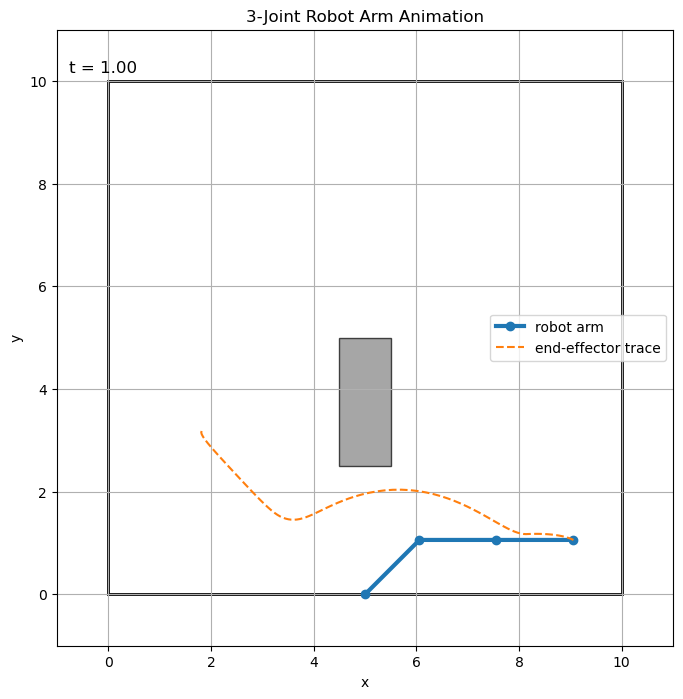

In [25]:
config_str = "config4"
CSV_PATH = "../results/" + config_str +"/trajectory.csv"
MAP_PATH = "../maps/map3.json"

# Robot parameters
LINK_LENGTHS = [1.5, 1.5, 1.5]   # lengths of the 3 links
BASE = np.array([5.0, 0.0])      # base position of the arm in workspace

# Animation settings
INTERVAL_MS = 100                # delay between frames in milliseconds
SHOW_TRACE = True               # set True to show end-effector trace
SAVE_MP4 = True                 # set True if you want to save animation
OUTPUT_MP4 = f"robot_animation_{config_str}.mp4"

traj = pd.read_csv(CSV_PATH)
map_data = load_map(MAP_PATH)

required_cols = {"t", "q1", "q2", "q3"}
if not required_cols.issubset(traj.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

times = traj["t"].to_numpy()
q_traj = traj[["q1", "q2", "q3"]].to_numpy()

# Plot setup
xmin, xmax, ymin, ymax = get_workspace_bounds(map_data)

fig, ax = plt.subplots(figsize=(8, 8))
draw_map(ax, map_data)

ax.set_xlim(xmin - 1, xmax + 1)
ax.set_ylim(ymin - 1, ymax + 1)
ax.set_aspect("equal")
ax.set_title("3-Joint Robot Arm Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

# Initial robot drawing
xs, ys = forward_kinematics(q_traj[0], LINK_LENGTHS, BASE)
arm_line, = ax.plot(xs, ys, "-o", linewidth=3, markersize=6, label="robot arm")
time_text = ax.text(
    0.02, 0.95, f"t = {times[0]:.2f}",
    transform=ax.transAxes, fontsize=12, verticalalignment="top"
)

ee_trace_x = []
ee_trace_y = []
trace_line = None
if SHOW_TRACE:
    trace_line, = ax.plot([], [], "--", linewidth=1.5, label="end-effector trace")

ax.legend()

def update(frame_idx):
    q = q_traj[frame_idx]
    xs, ys = forward_kinematics(q, LINK_LENGTHS, BASE)

    arm_line.set_data(xs, ys)
    time_text.set_text(f"t = {times[frame_idx]:.2f}")

    if SHOW_TRACE:
        ee_trace_x.append(xs[-1])
        ee_trace_y.append(ys[-1])
        trace_line.set_data(ee_trace_x, ee_trace_y)
        return arm_line, trace_line, time_text

    return arm_line, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(q_traj),
    interval=INTERVAL_MS,
    blit=False,
    repeat=False
)

if SAVE_MP4:
    anim.save(OUTPUT_MP4, writer="ffmpeg", fps=max(1, 1000 // INTERVAL_MS))
    print(f"Saved animation to {OUTPUT_MP4}")

plt.show()



In [ ]:
config_str = "config5"
CSV_PATH = "../results/" + config_str +"/trajectory.csv"
MAP_PATH = "../maps/map4.json"

# Robot parameters
LINK_LENGTHS = [1.5, 1.5, 1.5]   # lengths of the 3 links
BASE = np.array([5.0, 0.0])      # base position of the arm in workspace

# Animation settings
INTERVAL_MS = 100                # delay between frames in milliseconds
SHOW_TRACE = True               # set True to show end-effector trace
SAVE_MP4 = True                 # set True if you want to save animation
OUTPUT_MP4 = f"robot_animation_{config_str}.mp4"

traj = pd.read_csv(CSV_PATH)
map_data = load_map(MAP_PATH)

required_cols = {"t", "q1", "q2", "q3"}
if not required_cols.issubset(traj.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

times = traj["t"].to_numpy()
q_traj = traj[["q1", "q2", "q3"]].to_numpy()

# Plot setup
xmin, xmax, ymin, ymax = get_workspace_bounds(map_data)

fig, ax = plt.subplots(figsize=(8, 8))
draw_map(ax, map_data)

ax.set_xlim(xmin - 1, xmax + 1)
ax.set_ylim(ymin - 1, ymax + 1)
ax.set_aspect("equal")
ax.set_title("3-Joint Robot Arm Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

# Initial robot drawing
xs, ys = forward_kinematics(q_traj[0], LINK_LENGTHS, BASE)
arm_line, = ax.plot(xs, ys, "-o", linewidth=3, markersize=6, label="robot arm")
time_text = ax.text(
    0.02, 0.95, f"t = {times[0]:.2f}",
    transform=ax.transAxes, fontsize=12, verticalalignment="top"
)

ee_trace_x = []
ee_trace_y = []
trace_line = None
if SHOW_TRACE:
    trace_line, = ax.plot([], [], "--", linewidth=1.5, label="end-effector trace")

ax.legend()

def update(frame_idx):
    q = q_traj[frame_idx]
    xs, ys = forward_kinematics(q, LINK_LENGTHS, BASE)

    arm_line.set_data(xs, ys)
    time_text.set_text(f"t = {times[frame_idx]:.2f}")

    if SHOW_TRACE:
        ee_trace_x.append(xs[-1])
        ee_trace_y.append(ys[-1])
        trace_line.set_data(ee_trace_x, ee_trace_y)
        return arm_line, trace_line, time_text

    return arm_line, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(q_traj),
    interval=INTERVAL_MS,
    blit=False,
    repeat=False
)

if SAVE_MP4:
    anim.save(OUTPUT_MP4, writer="ffmpeg", fps=max(1, 1000 // INTERVAL_MS))
    print(f"Saved animation to {OUTPUT_MP4}")

plt.show()



In [ ]:
config_str = "config4"
CSV_PATH = "../results/" + config_str +"/trajectory.csv"
MAP_PATH = "../maps/map3.json"

# Robot parameters
LINK_LENGTHS = [1.5, 1.5, 1.5]   # lengths of the 3 links
BASE = np.array([5.0, 0.0])      # base position of the arm in workspace

# Animation settings
INTERVAL_MS = 100                # delay between frames in milliseconds
SHOW_TRACE = True              # set True to show end-effector trace
SAVE_MP4 = True                 # set True if you want to save animation
OUTPUT_MP4 = f"robot_animation_{config_str}.mp4"

traj = pd.read_csv(CSV_PATH)
map_data = load_map(MAP_PATH)

required_cols = {"t", "q1", "q2", "q3"}
if not required_cols.issubset(traj.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

times = traj["t"].to_numpy()
q_traj = traj[["q1", "q2", "q3"]].to_numpy()

# Plot setup
xmin, xmax, ymin, ymax = get_workspace_bounds(map_data)

fig, ax = plt.subplots(figsize=(8, 8))
draw_map(ax, map_data)

ax.set_xlim(xmin - 1, xmax + 1)
ax.set_ylim(ymin - 1, ymax + 1)
ax.set_aspect("equal")
ax.set_title("3-Joint Robot Arm Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

# Initial robot drawing
xs, ys = forward_kinematics(q_traj[0], LINK_LENGTHS, BASE)
arm_line, = ax.plot(xs, ys, "-o", linewidth=3, markersize=6, label="robot arm")
time_text = ax.text(
    0.02, 0.95, f"t = {times[0]:.2f}",
    transform=ax.transAxes, fontsize=12, verticalalignment="top"
)

ee_trace_x = []
ee_trace_y = []
trace_line = None
if SHOW_TRACE:
    trace_line, = ax.plot([], [], "--", linewidth=1.5, label="end-effector trace")

ax.legend()

def update(frame_idx):
    q = q_traj[frame_idx]
    xs, ys = forward_kinematics(q, LINK_LENGTHS, BASE)

    arm_line.set_data(xs, ys)
    time_text.set_text(f"t = {times[frame_idx]:.2f}")

    if SHOW_TRACE:
        ee_trace_x.append(xs[-1])
        ee_trace_y.append(ys[-1])
        trace_line.set_data(ee_trace_x, ee_trace_y)
        return arm_line, trace_line, time_text

    return arm_line, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(q_traj),
    interval=INTERVAL_MS,
    blit=False,
    repeat=False
)

if SAVE_MP4:
    anim.save(OUTPUT_MP4, writer="ffmpeg", fps=max(1, 1000 // INTERVAL_MS))
    print(f"Saved animation to {OUTPUT_MP4}")

plt.show()



In [ ]:
config_str = "config6"
CSV_PATH = "../results/" + config_str +"/trajectory.csv"
MAP_PATH = "../maps/map5.json"

# Robot parameters
LINK_LENGTHS = [1.5, 1.5, 1.5]   # lengths of the 3 links
BASE = np.array([5.0, 0.0])      # base position of the arm in workspace

# Animation settings
INTERVAL_MS = 100                # delay between frames in milliseconds
SHOW_TRACE = True               # set True to show end-effector trace
SAVE_MP4 = True                 # set True if you want to save animation
OUTPUT_MP4 = f"robot_animation_{config_str}_smoother2.mp4"

traj = pd.read_csv(CSV_PATH)
map_data = load_map(MAP_PATH)

required_cols = {"t", "q1", "q2", "q3"}
if not required_cols.issubset(traj.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

times = traj["t"].to_numpy()
q_traj = traj[["q1", "q2", "q3"]].to_numpy()

# Plot setup
xmin, xmax, ymin, ymax = get_workspace_bounds(map_data)

fig, ax = plt.subplots(figsize=(8, 8))
draw_map(ax, map_data)

ax.set_xlim(xmin - 1, xmax + 1)
ax.set_ylim(ymin - 1, ymax + 1)
ax.set_aspect("equal")
ax.set_title("3-Joint Robot Arm Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

# Initial robot drawing
xs, ys = forward_kinematics(q_traj[0], LINK_LENGTHS, BASE)
arm_line, = ax.plot(xs, ys, "-o", linewidth=3, markersize=6, label="robot arm")
time_text = ax.text(
    0.02, 0.95, f"t = {times[0]:.2f}",
    transform=ax.transAxes, fontsize=12, verticalalignment="top"
)

ee_trace_x = []
ee_trace_y = []
trace_line = None
if SHOW_TRACE:
    trace_line, = ax.plot([], [], "--", linewidth=1.5, label="end-effector trace")

ax.legend()

def update(frame_idx):
    q = q_traj[frame_idx]
    xs, ys = forward_kinematics(q, LINK_LENGTHS, BASE)

    arm_line.set_data(xs, ys)
    time_text.set_text(f"t = {times[frame_idx]:.2f}")

    if SHOW_TRACE:
        ee_trace_x.append(xs[-1])
        ee_trace_y.append(ys[-1])
        trace_line.set_data(ee_trace_x, ee_trace_y)
        return arm_line, trace_line, time_text

    return arm_line, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(q_traj),
    interval=INTERVAL_MS,
    blit=False,
    repeat=False
)

if SAVE_MP4:
    anim.save(OUTPUT_MP4, writer="ffmpeg", fps=max(1, 1000 // INTERVAL_MS))
    print(f"Saved animation to {OUTPUT_MP4}")

plt.show()

